<a href="https://colab.research.google.com/github/ErickEA1995/Projects/blob/main/ABM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import drive
 drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Mounted at /content/drive


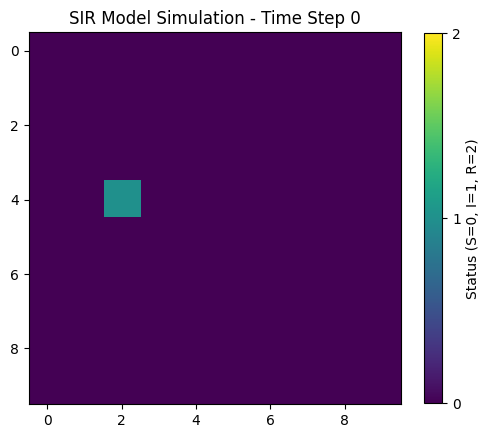

Time Step: 0/10
Number of Susceptible Agents: 99
Number of Infected Agents: 1
Number of Recovered Agents: 0



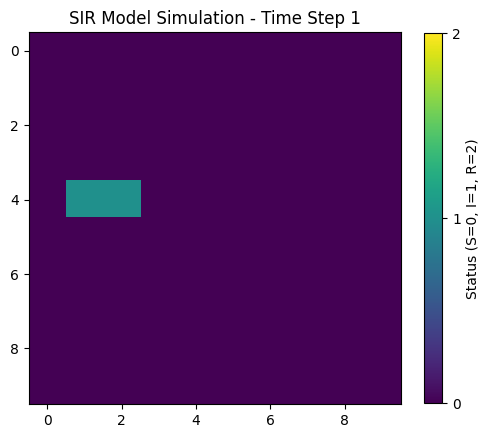

Time Step: 1/10
Number of Susceptible Agents: 98
Number of Infected Agents: 2
Number of Recovered Agents: 0



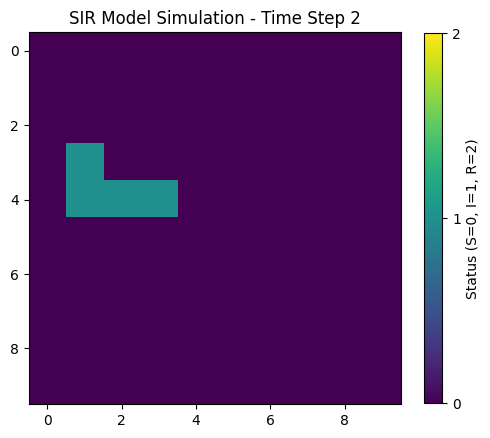

Time Step: 2/10
Number of Susceptible Agents: 96
Number of Infected Agents: 4
Number of Recovered Agents: 0



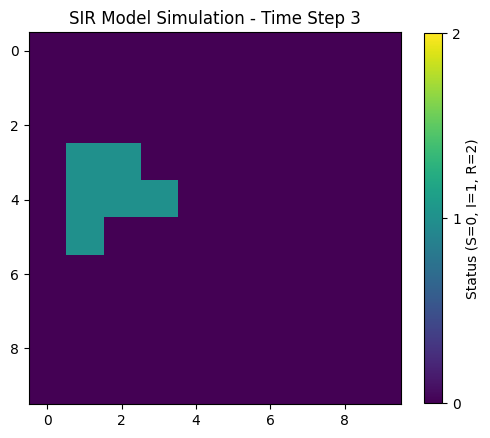

Time Step: 3/10
Number of Susceptible Agents: 94
Number of Infected Agents: 6
Number of Recovered Agents: 0



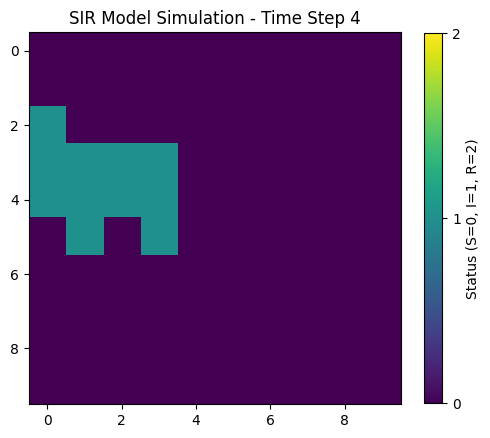

Time Step: 4/10
Number of Susceptible Agents: 89
Number of Infected Agents: 11
Number of Recovered Agents: 0



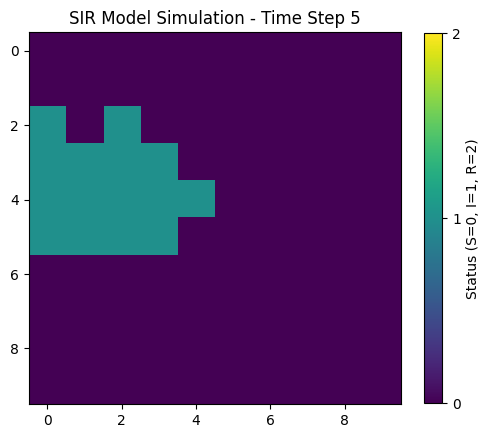

Time Step: 5/10
Number of Susceptible Agents: 85
Number of Infected Agents: 15
Number of Recovered Agents: 0



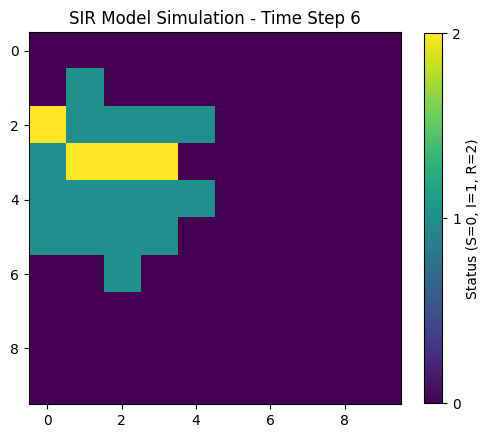

Time Step: 6/10
Number of Susceptible Agents: 80
Number of Infected Agents: 16
Number of Recovered Agents: 4



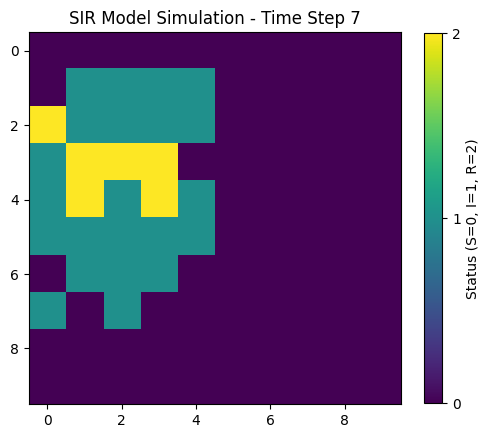

Time Step: 7/10
Number of Susceptible Agents: 72
Number of Infected Agents: 22
Number of Recovered Agents: 6



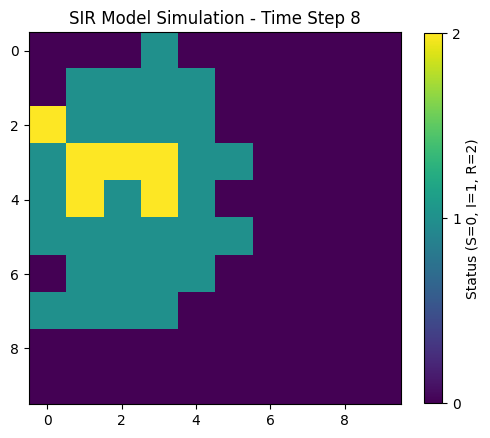

Time Step: 8/10
Number of Susceptible Agents: 65
Number of Infected Agents: 29
Number of Recovered Agents: 6



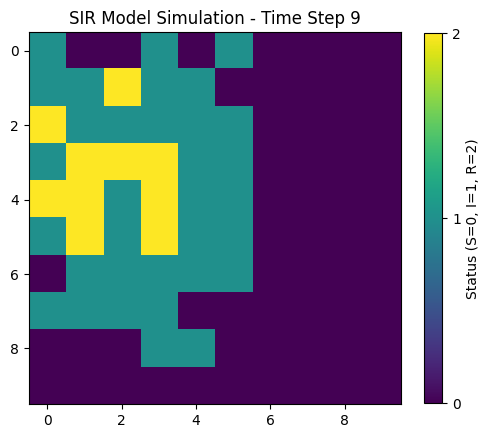

Time Step: 9/10
Number of Susceptible Agents: 57
Number of Infected Agents: 33
Number of Recovered Agents: 10



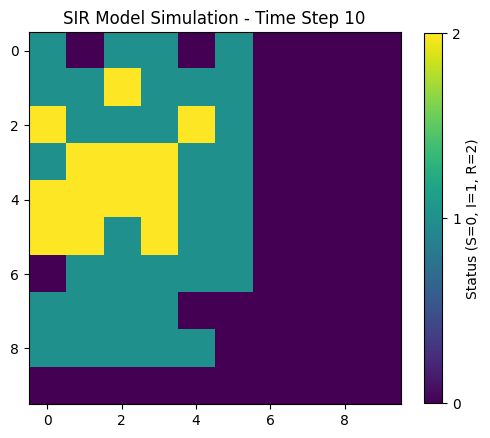

Time Step: 10/10
Number of Susceptible Agents: 52
Number of Infected Agents: 35
Number of Recovered Agents: 13



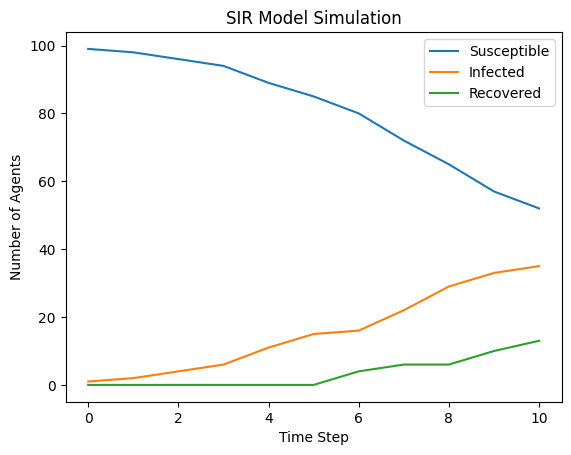

"\nplt.hist([agent.days_infected for agent in agents if agent.status == 'I' or agent.status =='R] color='blue', label='Infected')\nplt.xlabel('Days Infected')\nplt.ylabel('Frequency')\nplt.title('Distribution of Days Infected for Infected Agents')\nplt.legend()\nplt.show()\n"

In [ ]:

#Model 1 before corrections
from ast import Pass
import sys
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import poisson
from google.colab import drive

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=True)  # Use force_remount to handle potential issues
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

class Agent:
  def __init__(self, position):
    self.position = position
    self.status = 'S'
    self.history = []
    self.prev_status = 'S'
    self.days_infected = 0  # Initialize days_infected as an instance variable

  def x(self) -> int:
    return self.position[0]

  def y(self) -> int:
    return self.position[1]

  def update_position(self, new_position):
    self.position = new_position

  def update_status(self, new_status):
    self.prev_status = self.status
    self.status = new_status
    self.history.append(new_status)
    if new_status == 'I':
      self.days_infected += 1 #Increment days infected when status is I



  def status(self):
    return self.status

  def history(self):
    return self.history

  def days_infected(self):
    return self.days_infected

  def copy(self):
    return Agent(self.position, self.status)

  def __iter__(self):
        return self

  def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        value = self.data[self.index]
        self.index += 1
        return value

# Simulation parameters
grid_size = 10  # Size of the lattice
num_agents = 100  # Number of agents
initial_infected = 1  # Initial number of infected agents
infection_probability = 0.2  # Probability of infection when interacting with infected neighbor
recovery_time = 7  # Average recovery time when infected
time_steps = 10  # Number of time steps
sir_data = []
#Create a list of S, I, R at time step t.
#List = [(Sim,t,S,I,R)]

def initialize_agents(grid_size, num_agents) -> list:
    """Initializes agent positions and states on the grid."""
    agents = list()
    positions = list()
    for _ in range(num_agents):
      while True:
        pos = (random.randint(0, grid_size - 1), random.randint(0, grid_size - 1))
        if pos not in positions:
            positions.append(pos)
            break
    for i in range(num_agents):
        agents.append(Agent(positions[i]))
           # 'S' for susceptible, 'I' for infected, 'R' for recovered
    # Infect initial agents randomly
    for _ in range(initial_infected):
        agent_index = random.randint(0, num_agents - 1)
        agents[agent_index].update_status('I')
    return agents #returns agents to be assigned to the agents variable


def update_agents(agents, grid_size, infection_probability, recovery_probability):
    #loop through agents created
    for agent in agents:
        if agent.status == 'I':
            # Recovery
            #Get probability of recovery based on days infected
            recovery_prob = poisson.cdf(agent.days_infected, recovery_probability) # Access the instance variable
            if(recovery_prob > random.random()):
               agent.update_status('R')
            else:
               agent.update_status('I')

        elif agent.status == 'S':
            # Check for infection from neighbors
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                  if dx == 0 and dy == 0:
                      continue  # Skip itself
                  elif agent.x() == 0 and dx == -1:
                      continue  # Skip left edge
                  elif agent.x() == grid_size - 1 and dx == 1:
                      continue  # Skip right edge
                  elif agent.y() == 0 and dy == -1:
                      continue  # Skip bottom edge
                  elif agent.y() == grid_size - 1 and dy == 1:
                      continue  # Skip top edge

                  neighbor_pos = ((agent.x() + dx) % grid_size, (agent.y() + dy) % grid_size)


                  for other_agent in agents:
                      if other_agent.position == neighbor_pos and other_agent.prev_status == 'I':
                          if random.random() < infection_probability:
                              agent.update_status('I')
                              break
                if agent.status == 'I':
                  break


           #Add code where if sum of I's is 0 end simulation.
    return agents #Return agents to be assigned to agents variable


def visualize_grid(agents:list, grid_size, time_step):
  grid = [['S' for _ in range(grid_size)] for _ in range(grid_size)]
  for agent in agents:
    x = agent.x()
    y = agent.y()
    status = agent.status
    grid[x][y] = status

  plt.figure(figsize=(6, 6))
  plt.imshow(np.array([[{'S': 0, 'I': 1, 'R': 2}[cell] for cell in row] for row in grid]), cmap='viridis', vmin=0, vmax=2)
  plt.title(f"SIR Model Simulation - Time Step {time_step}")
  plt.colorbar(ticks=[0, 1, 2], label='Status (S=0, I=1, R=2)', shrink=0.8) #added colorbar with labels
  plt.show()


# Initialize and run the simulation
agents = initialize_agents(grid_size, num_agents)
agents2 = initialize_agents(grid_size, num_agents)
# Run the simulation for a specified number of time steps

for t in range(time_steps + 1):
    visualize_grid(agents, grid_size, t) #visualize each time step
    susceptible_count = sum(1 for agent in agents if agent.status == 'S')
    infected_count = sum(1 for agent in agents if agent.status == 'I')
    recovered_count = sum(1 for agent in agents if agent.status == 'R')
    sir_data.append([t, susceptible_count, infected_count, recovered_count])

    print(f"Time Step: {t}/{time_steps}")
    print("Number of Susceptible Agents:", susceptible_count)
    print("Number of Infected Agents:", infected_count)
    print("Number of Recovered Agents:", recovered_count)
    print()
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
 #assign agents to the return from update_agents
time = [row[0] for row in sir_data]
susceptible = [row[1] for row in sir_data]
infected = [row[2] for row in sir_data]
recovered = [row[3] for row in sir_data]

plt.plot(time, susceptible, label='Susceptible')
plt.plot(time, infected, label='Infected')
plt.plot(time, recovered, label='Recovered')
plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('SIR Model Simulation')
plt.legend()
plt.show()
'''
for t in range(time_steps + 1):
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
'''


'''
plt.hist([agent.days_infected for agent in agents if agent.status == 'I' or agent.status =='R] color='blue', label='Infected')
plt.xlabel('Days Infected')
plt.ylabel('Frequency')
plt.title('Distribution of Days Infected for Infected Agents')
plt.legend()
plt.show()
'''
#plot time courses from lists of simulation values
#mean, median, and std deviation

Mounted at /content/drive
Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 397
Number of Infected Agents: 3
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 394
Number of Infected Agents: 5
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 388
Number of Infected Agents: 10
Number of Recovered Agents: 2

Time Step: 4/20
Number of Susceptible Agents: 377
Number of Infected Agents: 15
Number of Recovered Agents: 8

Time Step: 5/20
Number of Susceptible Agents: 364
Number of Infected Agents: 24
Number of Recovered Agents: 12

Time Step: 6/20
Number of Susceptible Agents: 347
Number of Infected Agents: 31
Number of Recovered Agents: 22

Time Step: 7/20
Number of Susceptible Agents: 326
Number of Infected Agents: 42
Number of Recovered Agents: 32

Time Step: 8/20
Number of Susceptible Agents: 293
Number of Infected Agents: 63
Number

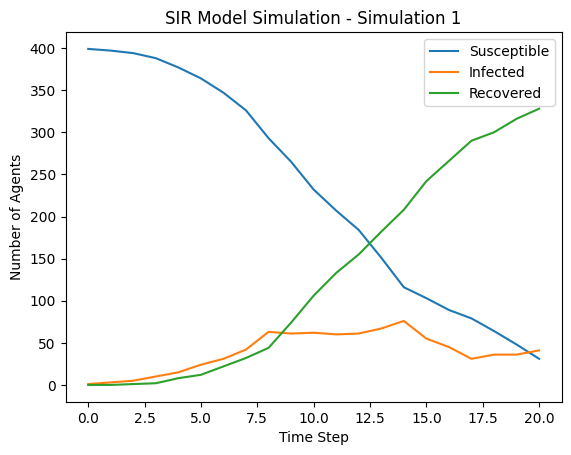

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 396
Number of Infected Agents: 4
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 391
Number of Infected Agents: 9
Number of Recovered Agents: 0

Time Step: 3/20
Number of Susceptible Agents: 386
Number of Infected Agents: 11
Number of Recovered Agents: 3

Time Step: 4/20
Number of Susceptible Agents: 378
Number of Infected Agents: 17
Number of Recovered Agents: 5

Time Step: 5/20
Number of Susceptible Agents: 367
Number of Infected Agents: 22
Number of Recovered Agents: 11

Time Step: 6/20
Number of Susceptible Agents: 353
Number of Infected Agents: 30
Number of Recovered Agents: 17

Time Step: 7/20
Number of Susceptible Agents: 345
Number of Infected Agents: 24
Number of Recovered Agents: 31

Time Step: 8/20
Number of Susceptible Agents: 335
Number of Infected Agents: 21
Number of Recovered Agents: 44



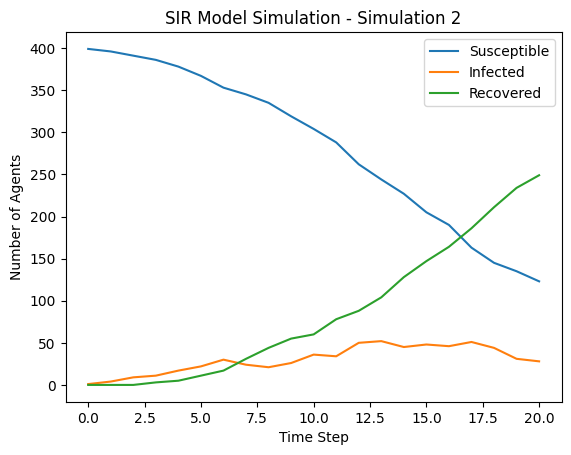

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 398
Number of Infected Agents: 2
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 397
Number of Infected Agents: 1
Number of Recovered Agents: 2

Time Step: 3/20
Number of Susceptible Agents: 395
Number of Infected Agents: 3
Number of Recovered Agents: 2

Time Step: 4/20
Number of Susceptible Agents: 394
Number of Infected Agents: 4
Number of Recovered Agents: 2

Time Step: 5/20
Number of Susceptible Agents: 389
Number of Infected Agents: 7
Number of Recovered Agents: 4

Time Step: 6/20
Number of Susceptible Agents: 387
Number of Infected Agents: 7
Number of Recovered Agents: 6

Time Step: 7/20
Number of Susceptible Agents: 378
Number of Infected Agents: 14
Number of Recovered Agents: 8

Time Step: 8/20
Number of Susceptible Agents: 374
Number of Infected Agents: 15
Number of Recovered Agents: 11

Time St

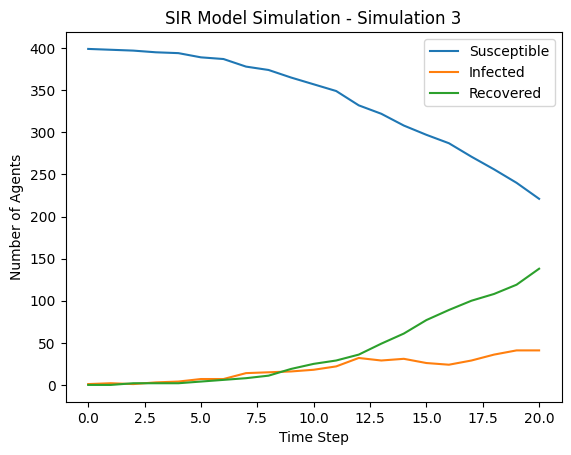

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 2/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 4/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 5/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 6/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 7/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 8/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step:

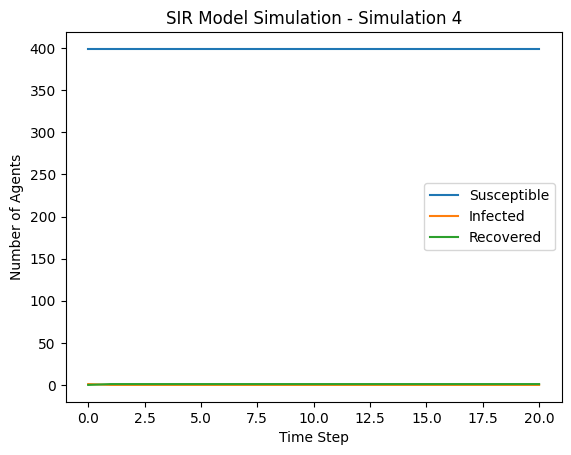

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 397
Number of Infected Agents: 3
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 392
Number of Infected Agents: 6
Number of Recovered Agents: 2

Time Step: 3/20
Number of Susceptible Agents: 386
Number of Infected Agents: 10
Number of Recovered Agents: 4

Time Step: 4/20
Number of Susceptible Agents: 378
Number of Infected Agents: 16
Number of Recovered Agents: 6

Time Step: 5/20
Number of Susceptible Agents: 366
Number of Infected Agents: 23
Number of Recovered Agents: 11

Time Step: 6/20
Number of Susceptible Agents: 350
Number of Infected Agents: 36
Number of Recovered Agents: 14

Time Step: 7/20
Number of Susceptible Agents: 329
Number of Infected Agents: 39
Number of Recovered Agents: 32

Time Step: 8/20
Number of Susceptible Agents: 305
Number of Infected Agents: 46
Number of Recovered Agents: 49



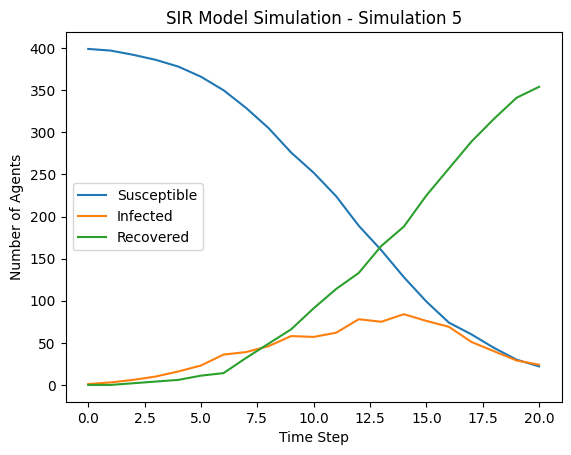

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 395
Number of Infected Agents: 5
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 394
Number of Infected Agents: 5
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 391
Number of Infected Agents: 7
Number of Recovered Agents: 2

Time Step: 4/20
Number of Susceptible Agents: 383
Number of Infected Agents: 11
Number of Recovered Agents: 6

Time Step: 5/20
Number of Susceptible Agents: 379
Number of Infected Agents: 11
Number of Recovered Agents: 10

Time Step: 6/20
Number of Susceptible Agents: 373
Number of Infected Agents: 14
Number of Recovered Agents: 13

Time Step: 7/20
Number of Susceptible Agents: 367
Number of Infected Agents: 13
Number of Recovered Agents: 20

Time Step: 8/20
Number of Susceptible Agents: 361
Number of Infected Agents: 16
Number of Recovered Agents: 23

T

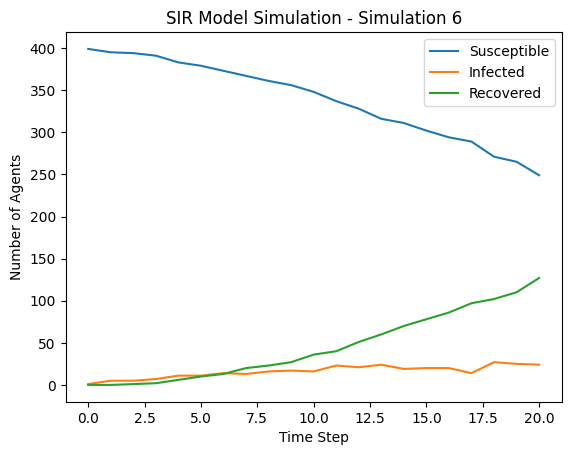

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 396
Number of Infected Agents: 3
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 390
Number of Infected Agents: 9
Number of Recovered Agents: 1

Time Step: 4/20
Number of Susceptible Agents: 383
Number of Infected Agents: 15
Number of Recovered Agents: 2

Time Step: 5/20
Number of Susceptible Agents: 369
Number of Infected Agents: 21
Number of Recovered Agents: 10

Time Step: 6/20
Number of Susceptible Agents: 355
Number of Infected Agents: 28
Number of Recovered Agents: 17

Time Step: 7/20
Number of Susceptible Agents: 346
Number of Infected Agents: 29
Number of Recovered Agents: 25

Time Step: 8/20
Number of Susceptible Agents: 333
Number of Infected Agents: 34
Number of Recovered Agents: 33

T

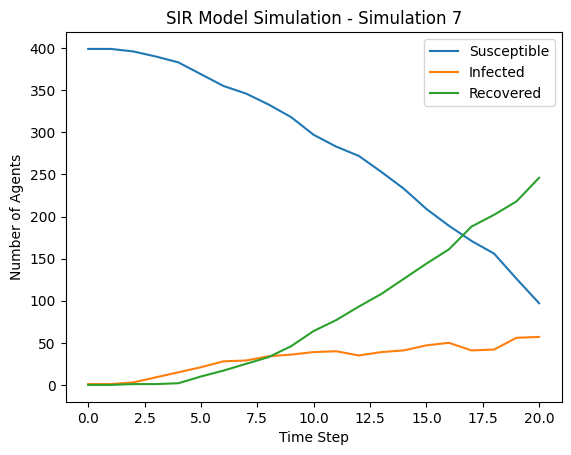

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 395
Number of Infected Agents: 5
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 393
Number of Infected Agents: 6
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 388
Number of Infected Agents: 8
Number of Recovered Agents: 4

Time Step: 4/20
Number of Susceptible Agents: 384
Number of Infected Agents: 12
Number of Recovered Agents: 4

Time Step: 5/20
Number of Susceptible Agents: 378
Number of Infected Agents: 12
Number of Recovered Agents: 10

Time Step: 6/20
Number of Susceptible Agents: 374
Number of Infected Agents: 10
Number of Recovered Agents: 16

Time Step: 7/20
Number of Susceptible Agents: 369
Number of Infected Agents: 11
Number of Recovered Agents: 20

Time Step: 8/20
Number of Susceptible Agents: 364
Number of Infected Agents: 12
Number of Recovered Agents: 24

T

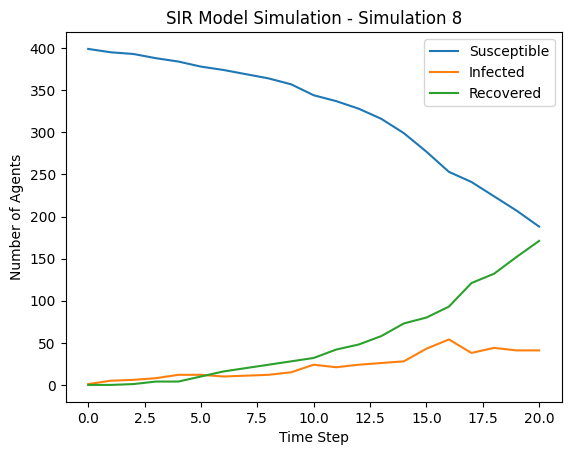

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 395
Number of Infected Agents: 5
Number of Recovered Agents: 0

Time Step: 2/20
Number of Susceptible Agents: 391
Number of Infected Agents: 8
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 378
Number of Infected Agents: 19
Number of Recovered Agents: 3

Time Step: 4/20
Number of Susceptible Agents: 366
Number of Infected Agents: 24
Number of Recovered Agents: 10

Time Step: 5/20
Number of Susceptible Agents: 347
Number of Infected Agents: 34
Number of Recovered Agents: 19

Time Step: 6/20
Number of Susceptible Agents: 331
Number of Infected Agents: 37
Number of Recovered Agents: 32

Time Step: 7/20
Number of Susceptible Agents: 305
Number of Infected Agents: 52
Number of Recovered Agents: 43

Time Step: 8/20
Number of Susceptible Agents: 285
Number of Infected Agents: 56
Number of Recovered Agents: 59


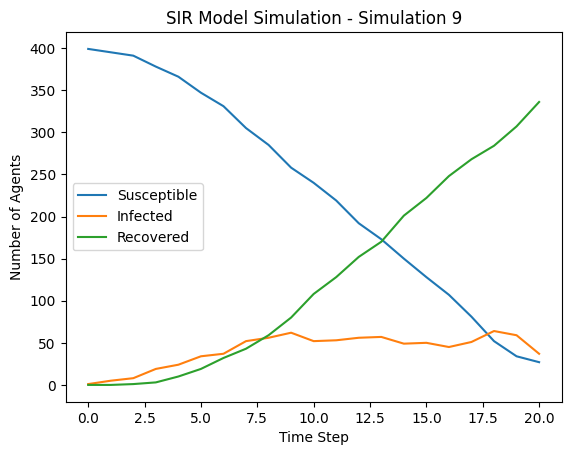

Time Step: 0/20
Number of Susceptible Agents: 399
Number of Infected Agents: 1
Number of Recovered Agents: 0

Time Step: 1/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 2/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 3/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 4/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 5/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 6/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 7/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step: 8/20
Number of Susceptible Agents: 399
Number of Infected Agents: 0
Number of Recovered Agents: 1

Time Step:

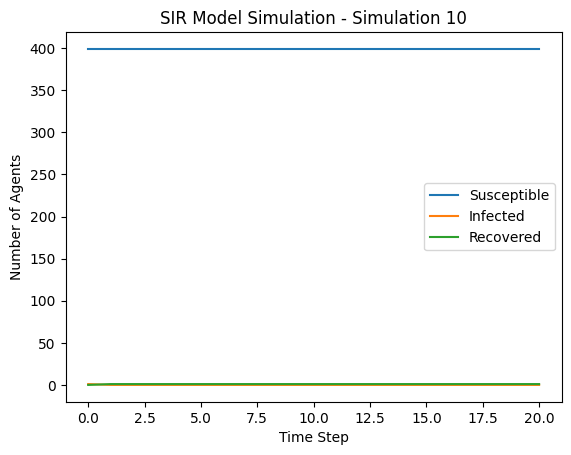

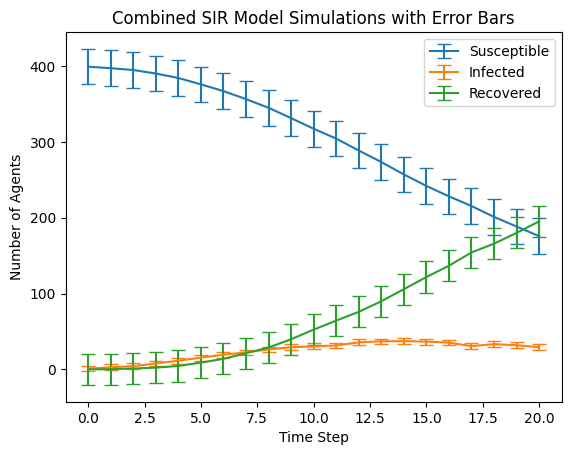

Average Recovery Time Across Simulations: 3.4090689821514712


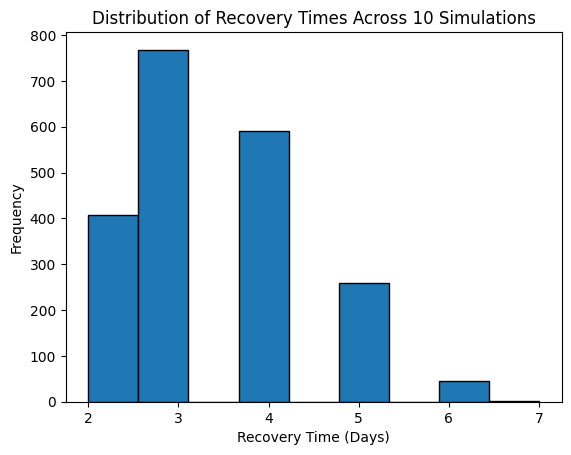

In [ ]:

from ast import Pass
import sys
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import poisson
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=True)  # Use force_remount to handle potential issues
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

class Agent:
  def __init__(self, position):
    self.position = position
    self.status = 'S'
    self.history = []
    self.prev_status = 'S'
    self.days_infected = 0  # Initialize days_infected as an instance variable

  def x(self) -> int:
    return self.position[0]

  def y(self) -> int:
    return self.position[1]

  def update_position(self, new_position):
    self.position = new_position

  def update_status(self, new_status):
    self.prev_status = self.status
    self.status = new_status
    self.history.append(new_status)
    if new_status == 'I':
      self.days_infected += 1 #Increment days infected when status is I
    elif new_status == 'R':
      self.days_infected += 1 #Account for the time step it took to recover
      self.prev_status = 'R'



  def status(self):
    return self.status

  def history(self):
    return self.history

  def days_infected(self):
    return self.days_infected

  def copy(self):
    return Agent(self.position, self.status)

  def __iter__(self):
        return self

  def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        value = self.data[self.index]
        self.index += 1
        return value

# Simulation parameters
grid_size = 20  # Size of the lattice
num_agents = grid_size * grid_size  # Number of agents
initial_infected = 1  # Initial number of infected agents
infection_probability = 0.5  # Probability of infection when interacting with infected neighbor
recovery_time = 3  # Average recovery time when infected
time_steps = 20  # Number of time steps
sir_data = []
num_simulations = 10 # Number of simulations to run
all_recovery_times = [] # Store recovery times from all simulations
combined_sir_data = list() #Store combined data from all simulations
avg_sir_data = list() #Store average data from all simulations

def combine_simulations(sir_data, sir_this_simulation) -> list:
    """Combines simulation data for multiple runs, preserving maximum length."""
    if not sir_data:
        return sir_this_simulation  # Return the first simulation's data if sir_data is empty
    if not sir_this_simulation:
        return sir_data  # Return existing data if current simulation is empty

    # Ensure both lists have the same length by extending the shorter one with zeros
    max_len = max(len(sir_data), len(sir_this_simulation))
    if len(sir_data) < max_len:
        sir_data.extend([[i, 0, 0, 0] for i in range(len(sir_data), max_len)])
    elif len(sir_this_simulation) < max_len:
        sir_this_simulation.extend([[i, 0, 0, 0] for i in range(len(sir_this_simulation), max_len)])

    combined_data = []
    for i in range(max_len):
        combined_data.append([
            sir_data[i][0],  # Time step
            sir_data[i][1] + sir_this_simulation[i][1],  # Susceptible
            sir_data[i][2] + sir_this_simulation[i][2],  # Infected
            sir_data[i][3] + sir_this_simulation[i][3],  # Recovered
        ])
    return combined_data

#Keep track of x - mean^2

def average_simulations(combined_sir_data, num_simulations):
    # Check if combined_sir_data is empty
    if not combined_sir_data:
        return []
    time = [row[0] for row in combined_sir_data]
    susceptible = [row[1]/num_simulations for row in combined_sir_data]
    infected = [row[2]/num_simulations for row in combined_sir_data]
    recovered = [row[3]/num_simulations for row in combined_sir_data]
    averaged_data = []
    for i in range(len(time)):
        averaged_data.append([
            time[i],
            susceptible[i],
            infected[i],
            recovered[i]
        ])
    return averaged_data

def initialize_agents(grid_size, num_agents) -> list:
    """Initializes agent positions and states on the grid."""
    agents = list()
    positions = list()
    for _ in range(num_agents):
      while True:
        pos = (random.randint(0, grid_size - 1), random.randint(0, grid_size - 1))
        if pos not in positions:
            positions.append(pos)
            break
    for i in range(num_agents):
        agents.append(Agent(positions[i]))
           # 'S' for susceptible, 'I' for infected, 'R' for recovered
    # Infect initial agents randomly
    for _ in range(initial_infected):
        agent_index = random.randint(0, num_agents - 1)
        agents[agent_index].update_status('I')
    return agents #returns agents to be assigned to the agents variable


def update_agents(agents, grid_size, infection_probability, recovery_probability):
    #loop through agents created
    for agent in agents:
        if agent.status == 'I':
            # Recovery
            #Get probability of recovery based on days infected
            recovery_prob = poisson.cdf(agent.days_infected, recovery_probability) # Access the instance variable
            if(recovery_prob > random.random()):
               agent.update_status('R')
            else:
               agent.update_status('I')

        elif agent.status == 'S':
            # Check for infection from neighbors
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                  if dx == 0 and dy == 0:
                      continue  # Skip itself
                  elif agent.x() == 0 and dx == -1:
                      continue  # Skip left edge
                  elif agent.x() == grid_size - 1 and dx == 1:
                      continue  # Skip right edge
                  elif agent.y() == 0 and dy == -1:
                      continue  # Skip bottom edge
                  elif agent.y() == grid_size - 1 and dy == 1:
                      continue  # Skip top edge

                  neighbor_pos = ((agent.x() + dx) % grid_size, (agent.y() + dy) % grid_size)


                  for other_agent in agents:
                      if other_agent.position == neighbor_pos and other_agent.prev_status == 'I':
                          if random.random() < infection_probability:
                              agent.update_status('I')
                              break
                if agent.status == 'I':
                  break


           #Add code where if sum of I's is 0 end simulation.
    return agents #Return agents to be assigned to agents variable


def visualize_grid(agents:list, grid_size, time_step):
  grid = [['S' for _ in range(grid_size)] for _ in range(grid_size)]
  #loop to randomly place agents on the grid.
  for agent in agents:
    x = agent.x()
    y = agent.y()
    status = agent.status
    grid[x][y] = status

  plt.figure(figsize=(6, 6))
  plt.imshow(np.array([[{'S': 0, 'I': 1, 'R': 2}[cell] for cell in row] for row in grid]), cmap='viridis', vmin=0, vmax=2)
  plt.title(f"SIR Model Simulation - Time Step {time_step}")
  plt.colorbar(ticks=[0, 1, 2], label='Status (S=0, I=1, R=2)', shrink=0.8) #added colorbar with labels
  plt.show()


for sim in range(num_simulations):
    agents = initialize_agents(grid_size, num_agents) #initialize grid
    sir_data_sim = list()  # Store SIR data for this simulation
    recovery_times_this_sim = list() # Store recovery times for the current simulation

    # Run the simulation for a specified number of time steps
    for t in range(time_steps + 1):
      #visualize_grid(agents, grid_size, t) #visualize each time step
      susceptible_count = sum(1 for agent in agents if agent.status == 'S')
      infected_count = sum(1 for agent in agents if agent.status == 'I')
      recovered_count = sum(1 for agent in agents if agent.status == 'R')
      sir_data_sim.append([t, susceptible_count, infected_count, recovered_count])

      #Uncomment this and visualize grid to view grids at each time step
      print(f"Time Step: {t}/{time_steps}")
      print("Number of Susceptible Agents:", susceptible_count)
      print("Number of Infected Agents:", infected_count)
      print("Number of Recovered Agents:", recovered_count)
      print()



      agents = update_agents(agents, grid_size, infection_probability, recovery_time)
    #assign agents to the return from update_agents


    for agent in agents:
      if agent.status == 'R' and agent.days_infected > 0:
          recovery_times_this_sim.append(agent.days_infected)

    #Combine data this sim with the overall data gathered from previous simulations
    #Comment this out if you desire to view all data on one plot
    combined_sir_data = combine_simulations(combined_sir_data, sir_data_sim)


     # Plot the SIR graph for this simulation
    time = [row[0] for row in sir_data_sim]
    susceptible = [row[1] for row in sir_data_sim]
    infected = [row[2] for row in sir_data_sim]
    recovered = [row[3] for row in sir_data_sim]

    plt.figure()  # Create a new figure for each simulation
    plt.plot(time, susceptible, label='Susceptible')
    plt.plot(time, infected, label='Infected')
    plt.plot(time, recovered, label='Recovered')
    plt.xlabel('Time Step')
    plt.ylabel('Number of Agents')
    plt.title(f'SIR Model Simulation - Simulation {sim + 1}')
    plt.legend()
    plt.show()

    all_recovery_times.extend(recovery_times_this_sim)

#Uncomment this to view all simulations on one plot
'''
time = [row[0] for row in sir_data]
susceptible = [row[1] for row in sir_data]
infected = [row[2] for row in sir_data]
recovered = [row[3] for row in sir_data]

plt.plot(time, susceptible, label='Susceptible')
plt.plot(time, infected, label='Infected')
plt.plot(time, recovered, label='Recovered')
plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('SIR Model Simulation')
plt.legend()
plt.show()
'''
'''
for t in range(time_steps + 1):
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
'''


# Average Results across all simulations
avg_sir_data = average_simulations(combined_sir_data, num_simulations)

#plot time courses from lists of simulation values
time = [row[0] for row in avg_sir_data]
susceptible = [row[1] for row in avg_sir_data]
infected = [row[2] for row in avg_sir_data]
recovered = [row[3] for row in avg_sir_data]

# Calculate standard deviations for error bars
#loop through each S, I, R, and compute standard deviation at each one.
std_susceptible = np.std([row[1] for row in avg_sir_data], axis=0) / np.sqrt(num_simulations)
std_infected = np.std([row[2] for row in avg_sir_data], axis=0) / np.sqrt(num_simulations)
std_recovered = np.std([row[3] for row in avg_sir_data], axis=0) / np.sqrt(num_simulations)


plt.errorbar(time, susceptible, yerr=std_susceptible, label='Susceptible', capsize=5)
plt.errorbar(time, infected, yerr=std_infected, label='Infected', capsize=5)
plt.errorbar(time, recovered, yerr=std_recovered, label='Recovered', capsize=5)

plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('Combined SIR Model Simulations with Error Bars')
plt.legend()
plt.show()

# Calculate average recovery times
average_recovery_time = np.mean(all_recovery_times) if all_recovery_times else 0  # Handle empty list

print("Average Recovery Time Across Simulations:", average_recovery_time)


# Plot Histogram of Recovery Periods
plt.hist(all_recovery_times, bins=9, edgecolor='black') # Adjust bins if needed
plt.xlabel("Recovery Time (Days)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Recovery Times Across {num_simulations} Simulations")
plt.show()

#mean, median, and std deviation

In each simulation how many did each infected infect. Then take average of this of each simulation.

How to handle the corners?
Can we say what we expect the R0 to be.

Need to observe R0 then learn an ODE to estimate parameters.

Need to create a library of terms for sparse regression.

Is there a way to incorporate information from variance?

Mounted at /content/drive


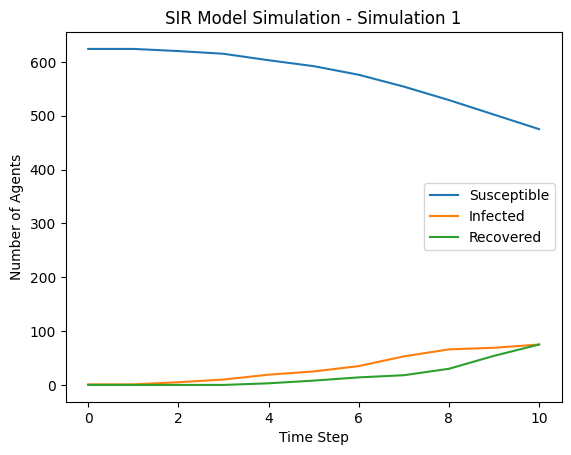

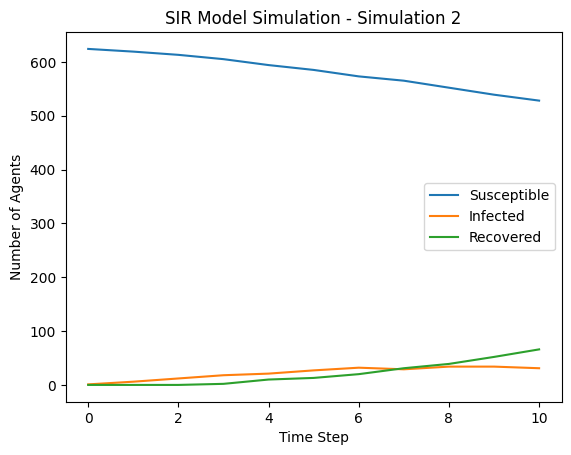

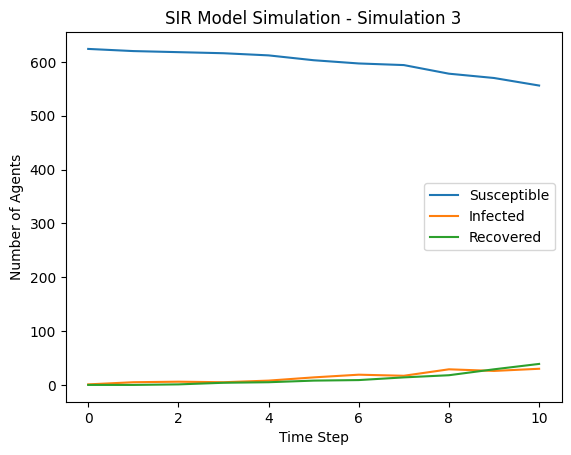

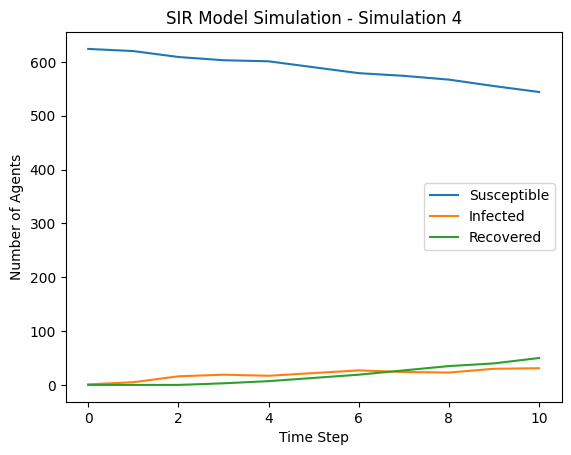

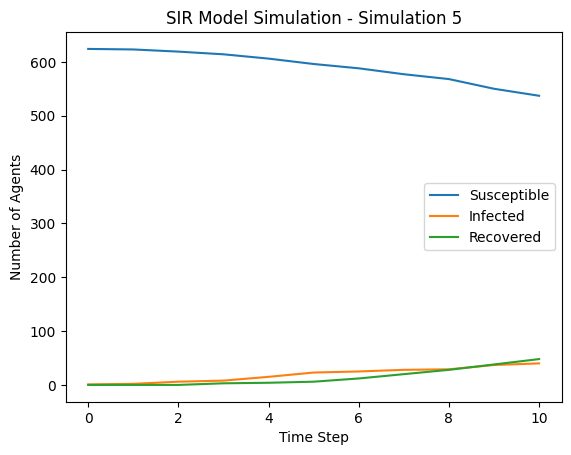

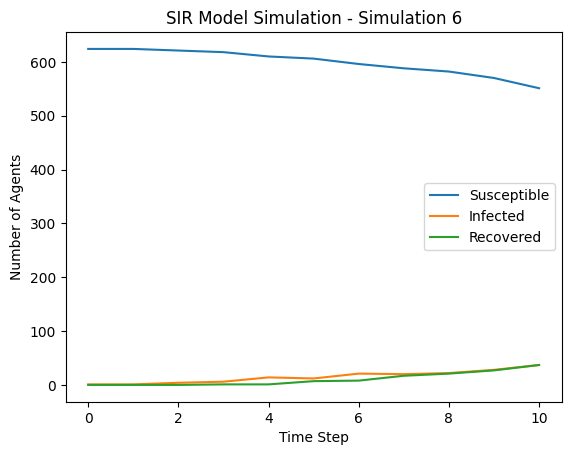

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-1-65f599446759>", line 226, in <cell line: 0>
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-1-65f599446759>", line None, in update_agents
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File 

In [ ]:
#Implement 3 d matrix to keep track of each simulation.
from ast import Pass
import sys
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import poisson
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=True)  # Use force_remount to handle potential issues
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

class Agent:
  def __init__(self, position):
    self.position = position
    self.status = 'S'
    self.history = []
    self.prev_status = 'S'
    self.days_infected = 0  # Initialize days_infected as an instance variable

  def x(self) -> int:
    return self.position[0]

  def y(self) -> int:
    return self.position[1]

  def update_position(self, new_position):
    self.position = new_position

  def update_status(self, new_status):
    self.prev_status = self.status
    self.status = new_status
    self.history.append(new_status)
    if new_status == 'I':
      self.days_infected += 1 #Increment days infected when status is I
    elif new_status == 'R':
      self.days_infected += 1 #Account for the time step it took to recover
      self.prev_status = 'R'



  def status(self):
    return self.status

  def history(self):
    return self.history

  def days_infected(self):
    return self.days_infected

  def copy(self):
    return Agent(self.position, self.status)

  def __iter__(self):
        return self

  def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        value = self.data[self.index]
        self.index += 1
        return value

# Simulation parameters
grid_size = 25  # Size of the lattice
num_agents = grid_size * grid_size  # Number of agents
initial_infected = 1  # Initial number of infected agents
infection_probability = 0.5  # Probability of infection when interacting with infected neighbor
recovery_time = 4  # Average recovery time when infected
time_steps = 10  # Number of time steps
sir_data = []
num_simulations = 10 # Number of simulations to run
all_recovery_times = [] # Store recovery times from all simulations
combined_sir_data = list() #Store combined data from all simulations
avg_sir_data = list() #Store average data from all simulations

def combine_simulations(sir_data, sir_this_simulation) -> list:
    """Combines simulation data for multiple runs, preserving maximum length."""
    if not sir_data:
        return sir_this_simulation  # Return the first simulation's data if sir_data is empty
    if not sir_this_simulation:
        return sir_data  # Return existing data if current simulation is empty

    # Ensure both lists have the same length by extending the shorter one with zeros
    max_len = max(len(sir_data), len(sir_this_simulation))
    if len(sir_data) < max_len:
        sir_data.extend([[i, 0, 0, 0] for i in range(len(sir_data), max_len)])
    elif len(sir_this_simulation) < max_len:
        sir_this_simulation.extend([[i, 0, 0, 0] for i in range(len(sir_this_simulation), max_len)])

    combined_data = []
    for i in range(max_len):
        combined_data.append([
            sir_data[i][0],  # Time step
            sir_data[i][1] + sir_this_simulation[i][1],  # Susceptible
            sir_data[i][2] + sir_this_simulation[i][2],  # Infected
            sir_data[i][3] + sir_this_simulation[i][3],  # Recovered
        ])
    return combined_data

#Keep track of x - mean^2

def average_simulations(combined_sir_data, num_simulations):
    # Check if combined_sir_data is empty
    if not combined_sir_data:
        return []
    time = [row[0] for row in combined_sir_data]
    susceptible = [row[1]/num_simulations for row in combined_sir_data]
    infected = [row[2]/num_simulations for row in combined_sir_data]
    recovered = [row[3]/num_simulations for row in combined_sir_data]
    averaged_data = []
    for i in range(len(time)):
        averaged_data.append([
            time[i],
            susceptible[i],
            infected[i],
            recovered[i]
        ])
    return averaged_data

def initialize_agents(grid_size, num_agents) -> list:
    """Initializes agent positions and states on the grid."""
    agents = list()
    positions = list()
    for _ in range(num_agents):
      while True:
        pos = (random.randint(0, grid_size - 1), random.randint(0, grid_size - 1))
        if pos not in positions:
            positions.append(pos)
            break
    for i in range(num_agents):
        agents.append(Agent(positions[i]))
           # 'S' for susceptible, 'I' for infected, 'R' for recovered
    # Infect initial agents randomly
    for _ in range(initial_infected):
        agent_index = random.randint(0, num_agents - 1)
        agents[agent_index].update_status('I')
    return agents #returns agents to be assigned to the agents variable


def update_agents(agents, grid_size, infection_probability, recovery_probability):
    #loop through agents created
    for agent in agents:
        if agent.status == 'I':
            # Recovery
            #Get probability of recovery based on days infected
            recovery_prob = poisson.cdf(agent.days_infected, recovery_probability) # Access the instance variable
            if(recovery_prob > random.random()):
               agent.update_status('R')
            else:
               agent.update_status('I')

        elif agent.status == 'S':
            # Check for infection from neighbors
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                  if dx == 0 and dy == 0:
                      continue  # Skip itself
                  elif agent.x() == 0 and dx == -1:
                      continue  # Skip left edge
                  elif agent.x() == grid_size - 1 and dx == 1:
                      continue  # Skip right edge
                  elif agent.y() == 0 and dy == -1:
                      continue  # Skip bottom edge
                  elif agent.y() == grid_size - 1 and dy == 1:
                      continue  # Skip top edge

                  neighbor_pos = ((agent.x() + dx) % grid_size, (agent.y() + dy) % grid_size)


                  for other_agent in agents:
                      if other_agent.position == neighbor_pos and other_agent.prev_status == 'I':
                          if random.random() < infection_probability:
                              agent.update_status('I')
                              break
                if agent.status == 'I':
                  break


           #Add code where if sum of I's is 0 end simulation.
    return agents #Return agents to be assigned to agents variable


def visualize_grid(agents:list, grid_size, time_step):
  grid = [['S' for _ in range(grid_size)] for _ in range(grid_size)]
  #loop to randomly place agents on the grid.
  for agent in agents:
    x = agent.x()
    y = agent.y()
    status = agent.status
    grid[x][y] = status

  plt.figure(figsize=(6, 6))
  plt.imshow(np.array([[{'S': 0, 'I': 1, 'R': 2}[cell] for cell in row] for row in grid]), cmap='viridis', vmin=0, vmax=2)
  plt.title(f"SIR Model Simulation - Time Step {time_step}")
  plt.colorbar(ticks=[0, 1, 2], label='Status (S=0, I=1, R=2)', shrink=0.8) #added colorbar with labels
  plt.show()

simulation_results = []  # List to store results from each simulation

for sim in range(num_simulations):
    agents = initialize_agents(grid_size, num_agents) #initialize grid
    sir_data_sim = list()  # Store SIR data for this simulation
    recovery_times_this_sim = list() # Store recovery times for the current simulation

    # Run the simulation for a specified number of time steps
    for t in range(time_steps + 1):
      #visualize_grid(agents, grid_size, t) #visualize each time step
      susceptible_count = sum(1 for agent in agents if agent.status == 'S')
      infected_count = sum(1 for agent in agents if agent.status == 'I')
      recovered_count = sum(1 for agent in agents if agent.status == 'R')
      sir_data_sim.append([t, susceptible_count, infected_count, recovered_count])

      #Uncomment this and visualize grid to view grids at each time step
      '''
      print(f"Time Step: {t}/{time_steps}")
      print("Number of Susceptible Agents:", susceptible_count)
      print("Number of Infected Agents:", infected_count)
      print("Number of Recovered Agents:", recovered_count)
      print()
      '''


      agents = update_agents(agents, grid_size, infection_probability, recovery_time)
    #assign agents to the return from update_agents


    for agent in agents:
      if agent.status == 'R' and agent.days_infected > 0:
          recovery_times_this_sim.append(agent.days_infected)

    #Combine data this sim with the overall data gathered from previous simulations
    #Comment this out if you desire to view all data on one plot
    combined_sir_data = combine_simulations(combined_sir_data, sir_data_sim)

    #store data from this sim
    simulation_results.append({
        'sir_data': sir_data_sim,
        'recovery_times': recovery_times_this_sim
    })

     # Plot the SIR graph for this simulation
    time = [row[0] for row in sir_data_sim]
    susceptible = [row[1] for row in sir_data_sim]
    infected = [row[2] for row in sir_data_sim]
    recovered = [row[3] for row in sir_data_sim]

    plt.figure()  # Create a new figure for each simulation
    plt.plot(time, susceptible, label='Susceptible')
    plt.plot(time, infected, label='Infected')
    plt.plot(time, recovered, label='Recovered')
    plt.xlabel('Time Step')
    plt.ylabel('Number of Agents')
    plt.title(f'SIR Model Simulation - Simulation {sim + 1}')
    plt.legend()
    plt.show()

    all_recovery_times.extend(recovery_times_this_sim)

#Uncomment this to view all simulations on one plot
'''
time = [row[0] for row in sir_data]
susceptible = [row[1] for row in sir_data]
infected = [row[2] for row in sir_data]
recovered = [row[3] for row in sir_data]

plt.plot(time, susceptible, label='Susceptible')
plt.plot(time, infected, label='Infected')
plt.plot(time, recovered, label='Recovered')
plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('SIR Model Simulation')
plt.legend()
plt.show()
'''
'''
for t in range(time_steps + 1):
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
'''


# Average Results across all simulations
avg_sir_data = average_simulations(combined_sir_data, num_simulations)

#plot time courses from lists of simulation values
time = [row[0] for row in avg_sir_data]
susceptible = [row[1] for row in avg_sir_data]
infected = [row[2] for row in avg_sir_data]
recovered = [row[3] for row in avg_sir_data]

# Calculate standard deviations for error bars
#loop through each S, I, R, and compute standard deviation at each one.
# Calculate standard deviations for each state at each time step
max_time_steps = max([len(sim['sir_data']) for sim in simulation_results])

susceptible_std_list = []
infected_std_list = []
recovered_std_list = []
for t in range(max_time_steps):
  susceptible_at_t = [sim['sir_data'][t][1] if t < len(sim['sir_data']) else 0 for sim in simulation_results]
  infected_at_t = [sim['sir_data'][t][2] if t < len(sim['sir_data']) else 0 for sim in simulation_results]
  recovered_at_t = [sim['sir_data'][t][3] if t < len(sim['sir_data']) else 0 for sim in simulation_results]

  susceptible_std_list.append(np.std(susceptible_at_t))
  infected_std_list.append(np.std(infected_at_t))
  recovered_std_list.append(np.std(recovered_at_t))

  print(susceptible_std_list)
  print(infected_std_list)
  print(recovered_std_list)

# Plot the average SIR data with standard deviation as error bars
time = [row[0] for row in avg_sir_data]
susceptible = [row[1] for row in avg_sir_data]
infected = [row[2] for row in avg_sir_data]
recovered = [row[3] for row in avg_sir_data]

plt.errorbar(time, susceptible, yerr=susceptible_std_list, label='Susceptible', capsize=5)
plt.errorbar(time, infected, yerr=infected_std_list, label='Infected', capsize=5)
plt.errorbar(time, recovered, yerr=recovered_std_list, label='Recovered', capsize=5)

plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('Combined SIR Model Simulations with Error Bars')
plt.legend()
plt.show()

# Calculate average recovery times
average_recovery_time = np.mean(all_recovery_times) if all_recovery_times else 0  # Handle empty list

print("Average Recovery Time Across Simulations:", average_recovery_time)

# Plot Histogram of Recovery Periods
plt.hist(all_recovery_times, bins=9, edgecolor='black')  # Adjust bins if needed
plt.xlabel("Recovery Time (Days)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Recovery Times Across {num_simulations} Simulations")
plt.show()


[  0.           1.5713484    3.05505046   6.76227736   9.39003938
  14.55343496  17.973918    23.30474439  29.219476    36.2981481
  44.83495109  54.49453478  65.30630582  75.15761217  84.80959065
  97.58200097 110.51339229 119.11536062 127.46803037 134.09449405
 137.94443326 139.5485667  139.84206259 139.62250694 136.83657009
 130.6520211  124.52735333 113.23917657 103.21797623  92.98267461
   0.        ]
[ 0.          1.5713484   3.17785548  6.4978629   9.0034287  12.50777536
 15.14701617 16.42791963 20.93375796 23.62411407 26.00427315 30.71734942
 37.05784601 41.91113468 42.5191315  46.26974053 43.1889332  43.92783082
 39.04350217 39.16284457 33.65327933 26.35980854 21.00499647 20.53241941
 22.41912764 20.90424967 31.48348577 37.24990679 42.78571355 48.87575581
  0.        ]
[  0.           0.           0.31426968   0.68493489   1.15470054
   3.1661793    3.77123617   8.50417472  11.54700538  15.09803356
  20.77450955  25.96055888  31.75951301  39.44741773  47.44535518
  56.08613305

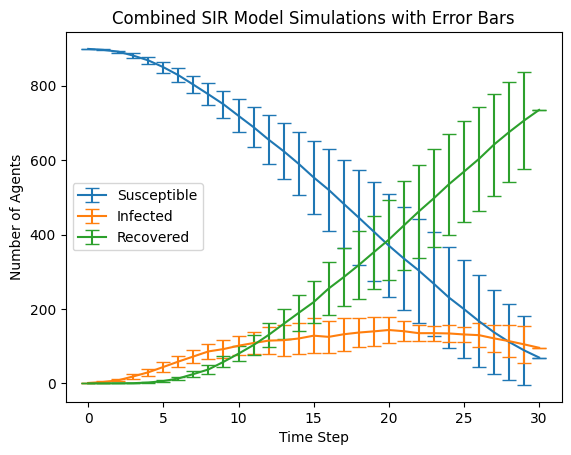

Average Recovery Time Across Simulations: 3.899372713016205


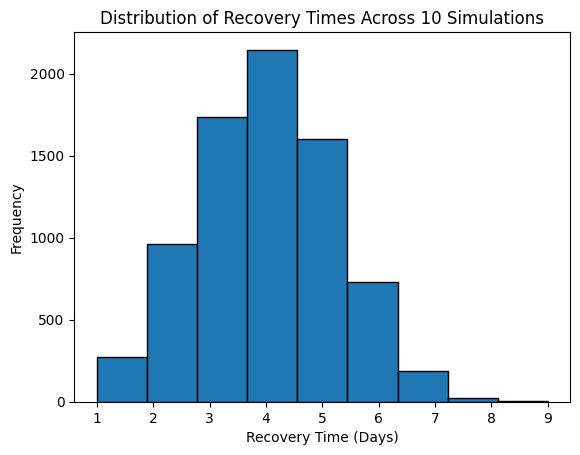

In [ ]:
#Implement running std dev. using Welford's algorithm
from ast import Pass
import sys
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import poisson
from google.colab import drive
import matplotlib.pyplot as plt
'''
# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=True)  # Use force_remount to handle potential issues
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
'''

class Agent:
  def __init__(self, position):
    self.position = position
    self.status = 'S'
    self.history = []
    self.prev_status = 'S'
    self.days_infected = 0  # Initialize days_infected as an instance variable

  def x(self) -> int:
    return self.position[0]

  def y(self) -> int:
    return self.position[1]

  def update_position(self, new_position):
    self.position = new_position

  def update_status(self, new_status):
    self.prev_status = self.status
    self.status = new_status
    self.history.append(new_status)
    if new_status == 'I':
      self.days_infected += 1 #Increment days infected when status is I
    elif new_status == 'R':
      self.prev_status = 'R'



  def status(self):
    return self.status

  def history(self):
    return self.history

  def days_infected(self):
    return self.days_infected

  def copy(self):
    return Agent(self.position, self.status)

  def __iter__(self):
        return self

  def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        value = self.data[self.index]
        self.index += 1
        return value

# Simulation parameters
grid_size = 30  # Size of the lattice
num_agents = grid_size * grid_size  # Number of agents
initial_infected = 1  # Initial number of infected agents
infection_probability = 0.6  # Probability of infection when interacting with infected neighbor
recovery_time = 5  # Average recovery time when infected
time_steps = 30  # Number of time steps
sir_data = []
num_simulations = 10 # Number of simulations to run
all_recovery_times = [] # Store recovery times from all simulations
combined_sir_data = list() #Store combined data from all simulations
avg_sir_data = list() #Store average data from all simulations

#Set up tracking arrays
means_S = np.zeros(time_steps + 1)
means_I = np.zeros(time_steps + 1)
means_R = np.zeros(time_steps + 1)

M2_S = np.zeros(time_steps + 1)
M2_I = np.zeros(time_steps + 1)
M2_R = np.zeros(time_steps + 1)
n_sim = 0

def update_running_stats(timestep_data, means, M2, n):
    # timestep_data: array of length T (data for one variable, one run)
    for t in range(len(timestep_data)):
      if n == 0:
        means[t] = timestep_data[t]
        continue

      x = timestep_data[t]
      delta = x - means[t]
      means[t] += delta / n
      M2[t] += delta * (x - means[t])  # uses the new mean



def combine_simulations(sir_data, sir_this_simulation) -> list:
    """Combines simulation data for multiple runs, preserving maximum length."""
    if not sir_data:
        return sir_this_simulation  # Return the first simulation's data if sir_data is empty
    if not sir_this_simulation:
        return sir_data  # Return existing data if current simulation is empty

    # Ensure both lists have the same length by extending the shorter one with zeros
    max_len = max(len(sir_data), len(sir_this_simulation))
    if len(sir_data) < max_len:
        sir_data.extend([[i, 0, 0, 0] for i in range(len(sir_data), max_len)])
    elif len(sir_this_simulation) < max_len:
        sir_this_simulation.extend([[i, 0, 0, 0] for i in range(len(sir_this_simulation), max_len)])

    combined_data = []
    for i in range(max_len):
        combined_data.append([
            sir_data[i][0],  # Time step
            sir_data[i][1] + sir_this_simulation[i][1],  # Susceptible
            sir_data[i][2] + sir_this_simulation[i][2],  # Infected
            sir_data[i][3] + sir_this_simulation[i][3],  # Recovered
        ])
    return combined_data

#Keep track of x - mean^2

def average_simulations(combined_sir_data, num_simulations):
    # Check if combined_sir_data is empty
    if not combined_sir_data:
        return []
    time = [row[0] for row in combined_sir_data]
    susceptible = [row[1]/num_simulations for row in combined_sir_data]
    infected = [row[2]/num_simulations for row in combined_sir_data]
    recovered = [row[3]/num_simulations for row in combined_sir_data]
    averaged_data = []
    for i in range(len(time)):
        averaged_data.append([
            time[i],
            susceptible[i],
            infected[i],
            recovered[i]
        ])
    return averaged_data



def initialize_agents(grid_size, num_agents) -> list:
    """Initializes agent positions and states on the grid."""
    agents = list()
    positions = list()
    for _ in range(num_agents):
      while True:
        pos = (random.randint(0, grid_size - 1), random.randint(0, grid_size - 1))
        if pos not in positions:
            positions.append(pos)
            break
    for i in range(num_agents):
        agents.append(Agent(positions[i]))
           # 'S' for susceptible, 'I' for infected, 'R' for recovered
    # Infect initial agents randomly
    for _ in range(initial_infected):
        agent_index = random.randint(0, num_agents - 1)
        agents[agent_index].update_status('I')
    return agents #returns agents to be assigned to the agents variable


def update_agents(agents, grid_size, infection_probability, recovery_probability):
    #loop through agents created
    for agent in agents:
        if agent.status == 'I':
            # Recovery
            #Get probability of recovery based on days infected
            recovery_prob = poisson.cdf(agent.days_infected, recovery_probability) # Access the instance variable
            if(recovery_prob > random.random()):
               agent.update_status('R')
            else:
               agent.update_status('I')

        elif agent.status == 'S':
            # Check for infection from neighbors
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                  if dx == 0 and dy == 0:
                      continue  # Skip itself
                  elif agent.x() == 0 and dx == -1:
                      continue  # Skip left edge
                  elif agent.x() == grid_size - 1 and dx == 1:
                      continue  # Skip right edge
                  elif agent.y() == 0 and dy == -1:
                      continue  # Skip bottom edge
                  elif agent.y() == grid_size - 1 and dy == 1:
                      continue  # Skip top edge

                  neighbor_pos = ((agent.x() + dx) % grid_size, (agent.y() + dy) % grid_size)


                  for other_agent in agents:
                      if other_agent.position == neighbor_pos and other_agent.prev_status == 'I':
                          if random.random() < infection_probability:
                              agent.update_status('I')
                              break
                if agent.status == 'I':
                  break


           #Add code where if sum of I's is 0 end simulation.
    return agents #Return agents to be assigned to agents variable


def visualize_grid(agents:list, grid_size, time_step):
  grid = [['S' for _ in range(grid_size)] for _ in range(grid_size)]
  #loop to randomly place agents on the grid.
  for agent in agents:
    x = agent.x()
    y = agent.y()
    status = agent.status
    grid[x][y] = status

  plt.figure(figsize=(6, 6))
  plt.imshow(np.array([[{'S': 0, 'I': 1, 'R': 2}[cell] for cell in row] for row in grid]), cmap='viridis', vmin=0, vmax=2)
  plt.title(f"SIR Model Simulation - Time Step {time_step}")
  plt.colorbar(ticks=[0, 1, 2], label='Status (S=0, I=1, R=2)', shrink=0.8) #added colorbar with labels
  plt.show()


for sim in range(num_simulations):
    agents = initialize_agents(grid_size, num_agents) #initialize grid
    sir_data_sim = list()  # Store SIR data for this simulation
    recovery_times_this_sim = list() # Store recovery times for the current simulation

    # Run the simulation for a specified number of time steps
    for t in range(time_steps + 1):
      #visualize_grid(agents, grid_size, t) #visualize each time step

      susceptible_count = sum(1 for agent in agents if agent.status == 'S')
      infected_count = sum(1 for agent in agents if agent.status == 'I')
      recovered_count = sum(1 for agent in agents if agent.status == 'R')
      sir_data_sim.append([t, susceptible_count, infected_count, recovered_count])


      '''
      #Uncomment this and visualize grid to view grids at each time step
      print(f"Time Step: {t}/{time_steps}")
      print("Number of Susceptible Agents:", susceptible_count)
      print("Number of Infected Agents:", infected_count)
      print("Number of Recovered Agents:", recovered_count)
      print()
      '''


      agents = update_agents(agents, grid_size, infection_probability, recovery_time)
    #assign agents to the return from update_agents


    for agent in agents:
      if agent.status == 'R' and agent.days_infected > 0:
          recovery_times_this_sim.append(agent.days_infected)

    #Combine data this sim with the overall data gathered from previous simulations
    #Comment this out if you desire to view all data on one plot
    combined_sir_data = combine_simulations(combined_sir_data, sir_data_sim)


     # Plot the SIR graph for this simulation
    time = [row[0] for row in sir_data_sim]
    susceptible = [row[1] for row in sir_data_sim]
    infected = [row[2] for row in sir_data_sim]
    recovered = [row[3] for row in sir_data_sim]

    update_running_stats(susceptible, means_S, M2_S, n_sim)
    update_running_stats(infected, means_I, M2_I, n_sim)
    update_running_stats(recovered, means_R, M2_R, n_sim)
    n_sim += 1

     # Plot the SIR graph for this simulation
    '''
    plt.figure()  # Create a new figure for each simulation
    plt.plot(time, susceptible, label='Susceptible')
    plt.plot(time, infected, label='Infected')
    plt.plot(time, recovered, label='Recovered')
    plt.xlabel('Time Step')
    plt.ylabel('Number of Agents')
    plt.title(f'SIR Model Simulation - Simulation {sim + 1}')
    plt.legend()
    plt.show()
    '''
    all_recovery_times.extend(recovery_times_this_sim)

#Uncomment this to view all simulations on one plot

'''
time = [row[0] for row in sir_data]
susceptible = [row[1] for row in sir_data]
infected = [row[2] for row in sir_data]
recovered = [row[3] for row in sir_data]

plt.plot(time, susceptible, label='Susceptible')
plt.plot(time, infected, label='Infected')
plt.plot(time, recovered, label='Recovered')
plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('SIR Model Simulation')
plt.legend()
plt.show()
'''
'''
for t in range(time_steps + 1):
    agents = update_agents(agents, grid_size, infection_probability, recovery_time)
'''


# Average Results across all simulations
avg_sir_data = average_simulations(combined_sir_data, num_simulations)
#Calculate std. Dev for each time step

std_S = np.zeros(time_steps + 1)
std_I = np.zeros(time_steps + 1)
std_R = np.zeros(time_steps + 1)

for t in range(time_steps):
 std_S[t] = np.sqrt(M2_S[t] / (n_sim - 1))
 std_I[t] = np.sqrt(M2_I[t] / (n_sim - 1))
 std_R[t] = np.sqrt(M2_R[t] / (n_sim - 1))

print(std_S)
print(std_I)
print(std_R)

#plot time courses from lists of simulation values
time = [row[0] for row in avg_sir_data]
susceptible = [row[1] for row in avg_sir_data]
infected = [row[2] for row in avg_sir_data]
recovered = [row[3] for row in avg_sir_data]

#

plt.errorbar(time, susceptible, yerr=std_S, label='Susceptible', capsize=5)
plt.errorbar(time, infected, yerr=std_I, label='Infected', capsize=5)
plt.errorbar(time, recovered, yerr=std_R, label='Recovered', capsize=5)

plt.xlabel('Time Step')
plt.ylabel('Number of Agents')
plt.title('Combined SIR Model Simulations with Error Bars')
plt.legend()
plt.show()

# Calculate average recovery times
average_recovery_time = np.mean(all_recovery_times) if all_recovery_times else 0  # Handle empty list

print("Average Recovery Time Across Simulations:", average_recovery_time)


# Plot Histogram of Recovery Periods
plt.hist(all_recovery_times, bins=9, edgecolor='black') # Adjust bins if needed
plt.xlabel("Recovery Time (Days)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Recovery Times Across {num_simulations} Simulations")
plt.show()

#Fix std deviation at end of simulations as well
#Network ABM Assuming well mixed and every agent connects to every other
#Connect to British born flu data and eyam plague data
#Sandy Anderson Mark Chaplain paper or Guillespi biochemical reaction algorithm
#

In [ ]:
!pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 11.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from scipy.integrate import solve_ivp
import pysindy as ps
from pysindy.feature_library import PolynomialLibrary
import math
import numpy as np
np.math = math


avg_simulation = np.column_stack((susceptible, infected, recovered))
feature_names = ["S", "I", "R"]
avg_simulation = pd.DataFrame(avg_simulation)
feature_names = ["S", "I", "R"]
avg_simulation.columns = feature_names
print(avg_simulation)

feature_lib=PolynomialLibrary(degree=2,include_bias=False)
dt = np.gradient(avg_simulation, axis=0)



#Looking into a conservative model, different ways to take the derivative


        S      I      R
0   899.0    1.0    0.0
1   896.4    3.6    0.0
2   891.7    8.2    0.1
3   881.0   18.6    0.4
4   868.2   29.7    2.1
5   849.9   44.0    6.1
6   828.4   58.5   13.1
7   802.9   72.2   24.9
8   776.9   85.8   37.3
9   750.2   92.1   57.7
10  719.2  101.1   79.7
11  688.7  108.3  103.0
12  655.2  114.8  130.0
13  624.2  116.0  159.8
14  590.2  120.5  189.3
15  553.6  128.1  218.3
16  520.2  124.9  254.9
17  482.6  131.9  285.5
18  445.6  136.5  317.9
19  407.9  139.7  352.4
20  370.3  143.4  386.3
21  335.6  140.1  424.3
22  303.1  134.8  462.1
23  267.5  134.9  497.6
24  230.7  134.1  535.2
25  199.6  131.4  569.0
26  167.1  129.5  603.4
27  137.2  120.9  641.9
28  111.3  113.4  675.3
29   88.7  104.8  706.5
30   69.4   95.6  735.0
Testing threshold: 0.0
(S)' = -0.001 S I + 0.002 I^2 + -0.001 I R
(I)' = -0.003 I^2 + 0.001 I R
(R)' = 0.001 I^2
--------------------
Testing threshold: 1e-05
(S)' = -0.001 S I + 0.003 I^2 + -0.001 I R
(I)' = 0.001 S I + -0.004 I^2 

In [ ]:
for threshold in np.arange(0, 0.0001, 0.00001):
    print(f"Testing threshold: {threshold}")
    model = ps.SINDy(feature_library=feature_lib,
                     feature_names=feature_names,
                     optimizer=ps.STLSQ(threshold=threshold))
    model.fit(avg_simulation, x_dot=dt)
    model.print()
    print("-" * 20) #separator